mic_pair_1: LPF order = 8
mic_pair_2: LPF order = 9
mic_pair_3: LPF order = 11


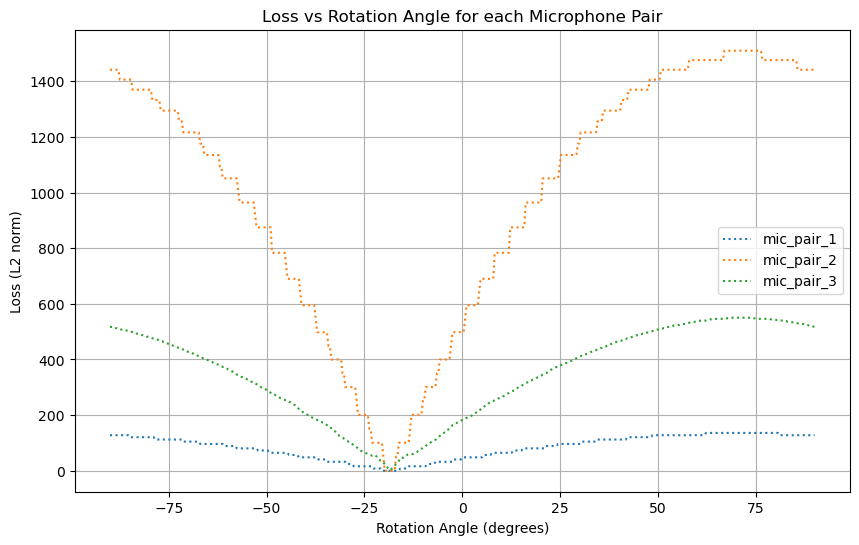

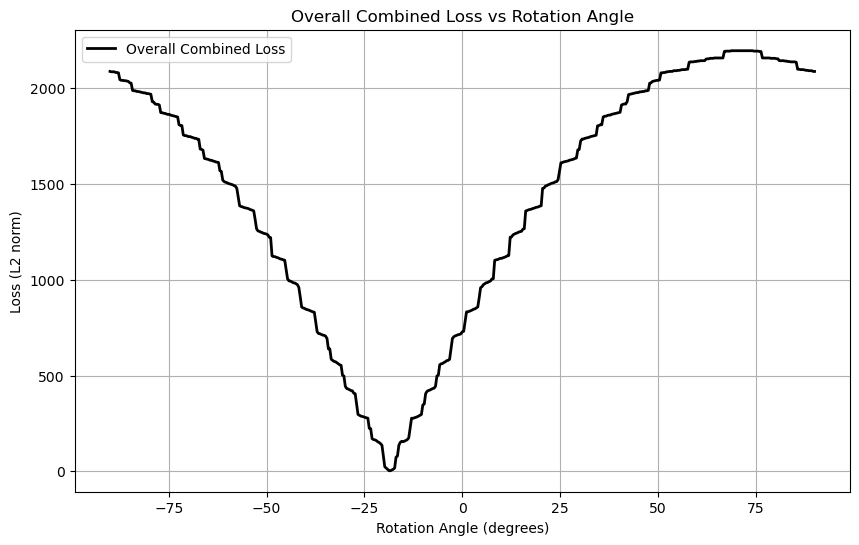

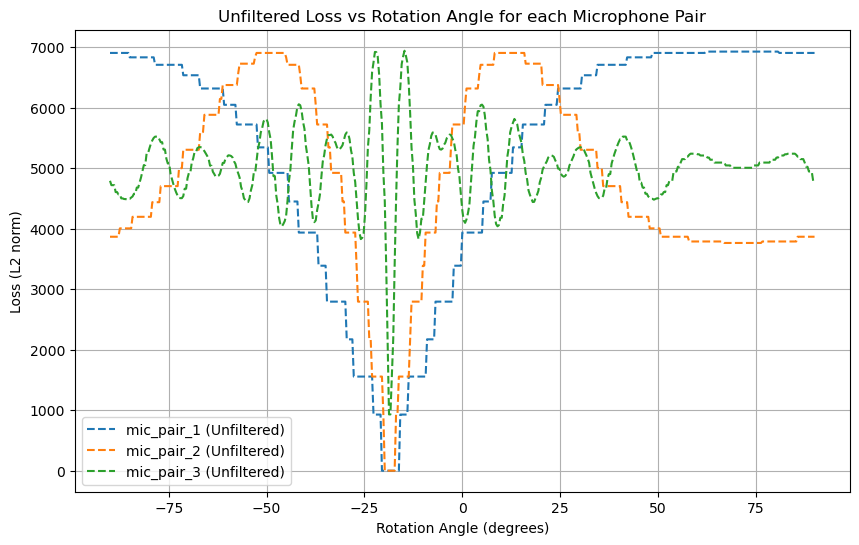

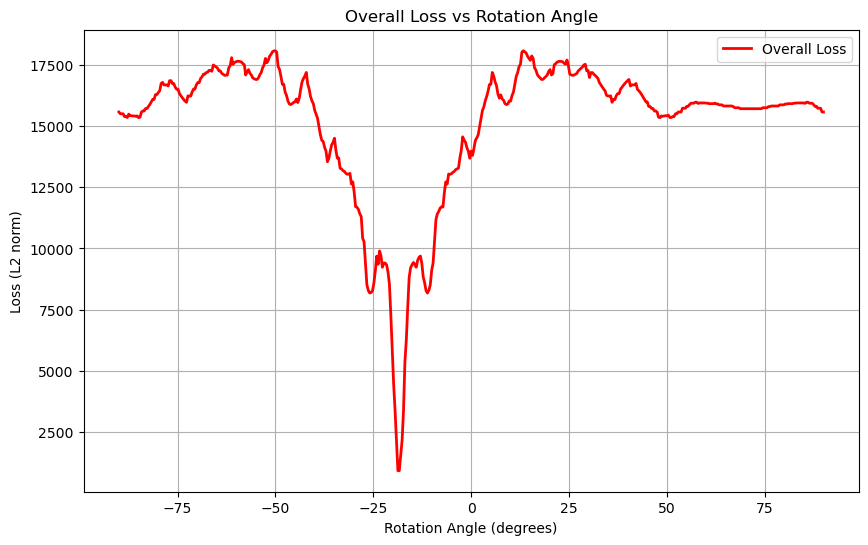

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, sosfilt, spectrogram
from IPython.display import Audio

# Constants
SOUND_SPEED = 343.2  # Speed of sound in air (m/s)
STOPBAND_FACTOR = 1.5  # Chosen multiplier to define the stopband frequency

# Define microphone pairs with unique positions and LPF parameters.
mic_pairs = {
    "mic_pair_1": {
        "positions": [np.array([-0.06, 0]), np.array([0.06, 0])],
        "lpf_params": {"cutoff": 250, "A_p": 1, "A_s": 20}  # 343.2/250 ≈ 1.37 m > 0.24 m separation
    },
    "mic_pair_2": {
        "positions": [np.array([-0.12, 0]), np.array([0.12, 0])],
        "lpf_params": {"cutoff": 400, "A_p": 1, "A_s": 25}  # 343.2/400 ≈ 0.86 m > 0.24 m separation
    },
    "mic_pair_3": {
        "positions": [np.array([-1, 0]), np.array([1, 0])], # 343.2/150 ≈ 2.29 m > 2 m separation.
        "lpf_params": {"cutoff": 150, "A_p": 1, "A_s": 30}
    }
}

# Function to calculate Butterworth filter order
def butterworth_order(A_p, A_s, omega_p, omega_s):
    return int(np.ceil(np.log10((10**(A_s/10) - 1) / (10**(A_p/10) - 1)) / (2 * np.log10(omega_s / omega_p))))

# Load audio file
folder_path = r'Bird_sound'
filename = "Bird_call.wav"  
file_path = os.path.join(folder_path, filename)
SR, y = wavfile.read(file_path)

# Display the audio 
display(Audio(y, rate=SR))

# Filter order for each microphone pair using LPF parameters
for pair_name, pair in mic_pairs.items():
    cutoff = pair["lpf_params"]["cutoff"]
    A_p = pair["lpf_params"]["A_p"]
    A_s = pair["lpf_params"]["A_s"]
    omega_p = cutoff / (SR / 2)
    omega_s = cutoff * STOPBAND_FACTOR / (SR / 2)
    order = butterworth_order(A_p, A_s, omega_p, omega_s)
    pair["lpf_params"]["order"] = order
    print(f"{pair_name}: LPF order = {order}")

# LPF function using second-order sections
def apply_lpf(signal_data, cutoff, order, fs):
    sos = butter(order, cutoff, btype='lp', fs=fs, output='sos')
    return sosfilt(sos, signal_data)

# Function to rotate a microphone pair about its own midpoint by a given angle
def rotate_mic_pair(angle, mic_positions):
    midpoint = (mic_positions[0] + mic_positions[1]) / 2
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
    return [midpoint + R @ (pos - midpoint) for pos in mic_positions]

# Function to compute loss for a given angle, sound source, and microphone pair.
def loss_angle_with_lpf_for_pair(angle, sound_source, mic_pair, SR):
    mic_positions = mic_pair["positions"]
    lpf_params = mic_pair["lpf_params"]
    rotated_mics = rotate_mic_pair(angle, mic_positions)
    mic1, mic2 = rotated_mics[0], rotated_mics[1]
    dist1 = np.linalg.norm(sound_source - mic1)
    dist2 = np.linalg.norm(sound_source - mic2)
    t1 = dist1 / SOUND_SPEED
    t2 = dist2 / SOUND_SPEED
    samples_delay1 = int(t1 * SR)
    samples_delay2 = int(t2 * SR)
    y1 = y[samples_delay1:]
    y2 = y[samples_delay2:]
    min_len = min(len(y1), len(y2))
    y1 = y1[:min_len]
    y2 = y2[:min_len]
    y1_filtered = apply_lpf(y1, lpf_params["cutoff"], lpf_params["order"], SR)
    y2_filtered = apply_lpf(y2, lpf_params["cutoff"], lpf_params["order"], SR)
    return np.linalg.norm(y1_filtered - y2_filtered)

# Define the sound source position
sound_source = np.array([1, 3])

# Define angles (in radians) for microphone rotation
angles = np.linspace(-np.pi/2, np.pi/2, 501)

# Plot losses for each microphone pair
plt.figure(figsize=(10, 6))
for pair_name, pair in mic_pairs.items():
    losses = np.array([loss_angle_with_lpf_for_pair(a, sound_source, pair, SR) for a in angles])
    plt.plot(np.degrees(angles), losses, label=f"{pair_name}", linestyle=':')
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Loss (L2 norm)")
plt.title("Loss vs Rotation Angle for each Microphone Pair")
plt.legend()
plt.grid(True)
plt.show()

# Compute and plot the overall combined loss
overall_loss = np.zeros_like(angles)
for pair_name, pair in mic_pairs.items():
    losses = np.array([loss_angle_with_lpf_for_pair(a, sound_source, pair, SR) for a in angles])
    overall_loss += losses

plt.figure(figsize=(10, 6))
plt.plot(np.degrees(angles), overall_loss, label="Overall Combined Loss", color='black', linewidth=2)
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Loss (L2 norm)")
plt.title("Overall Combined Loss vs Rotation Angle")
plt.legend()
plt.grid(True)
plt.show()

# Plot unfiltered loss for each microphone pair#
plt.figure(figsize=(10, 6))
for pair_name, pair in mic_pairs.items():
    losses_unfiltered = np.array([
        np.linalg.norm(y[int((np.linalg.norm(sound_source - rotate_mic_pair(a, pair["positions"])[0]) / SOUND_SPEED) * SR):][:1000] -
                        y[int((np.linalg.norm(sound_source - rotate_mic_pair(a, pair["positions"])[1]) / SOUND_SPEED) * SR):][:1000])
        for a in angles
    ])
    plt.plot(np.degrees(angles), losses_unfiltered, label=f"{pair_name} (Unfiltered)", linestyle='--')
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Loss (L2 norm)")
plt.title("Unfiltered Loss vs Rotation Angle for each Microphone Pair")
plt.legend()
plt.grid(True)
plt.show()

overall_loss_unfiltered = np.zeros_like(angles)
for pair_name, pair in mic_pairs.items():
    losses_unfiltered = np.array([
        np.linalg.norm(y[int((np.linalg.norm(sound_source - rotate_mic_pair(a, pair["positions"])[0]) / SOUND_SPEED) * SR):][:1000] -
                        y[int((np.linalg.norm(sound_source - rotate_mic_pair(a, pair["positions"])[1]) / SOUND_SPEED) * SR):][:1000])
        for a in angles
    ])
    overall_loss_unfiltered += losses_unfiltered

plt.figure(figsize=(10, 6))
plt.plot(np.degrees(angles), overall_loss_unfiltered, label="Overall Unfiltered Loss", color='red', linewidth=2)
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Loss (L2 norm)")
plt.title("Overall Unfiltered Loss vs Rotation Angle")
plt.legend()
plt.grid(True)
plt.show()


mic_pair_1: LPF order = 8
mic_pair_2: LPF order = 9
mic_pair_3: LPF order = 11


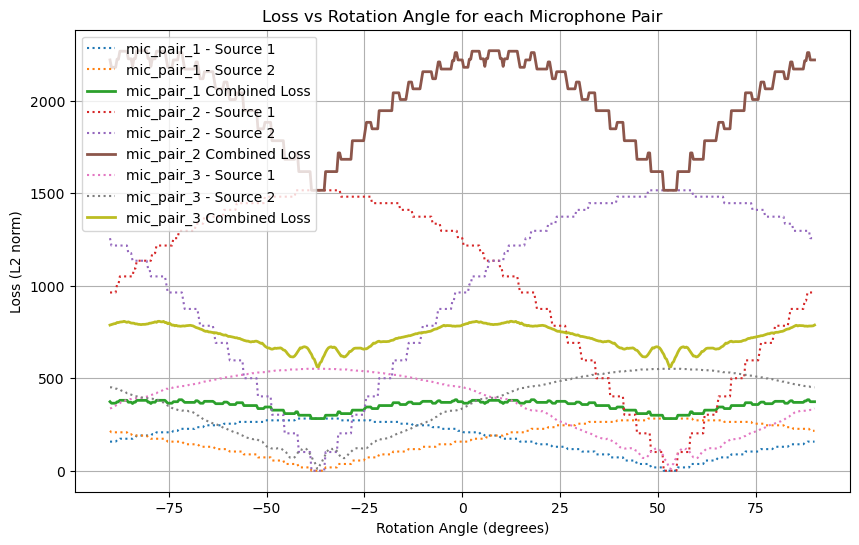

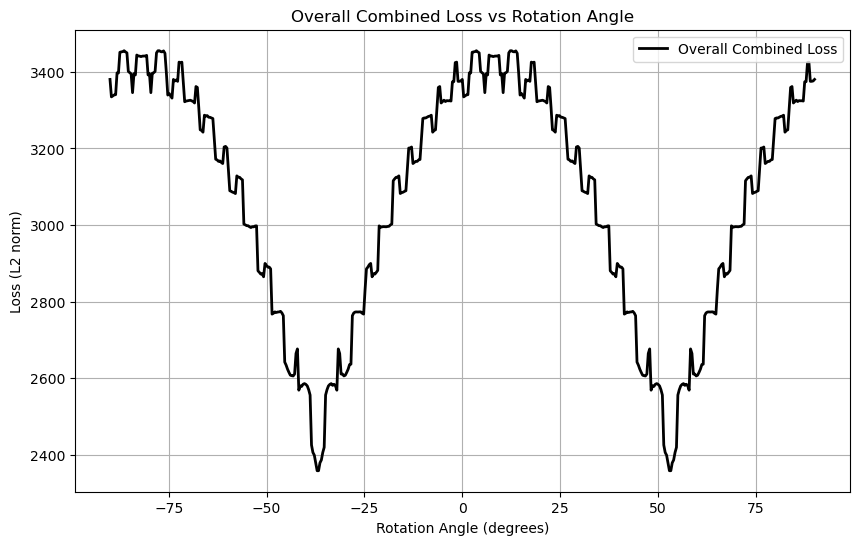

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, sosfilt, spectrogram
from IPython.display import Audio

# Constants
SOUND_SPEED = 343.2  # Speed of sound in air (m/s)
STOPBAND_FACTOR = 1.5  # Chosen multiplier to define the stopband frequency

# Define microphone pairs with unique positions and LPF parameters.
mic_pairs = {
    "mic_pair_1": {
        "positions": [np.array([-0.12, 0]), np.array([0.12, 0])],
        "lpf_params": {"cutoff": 250, "A_p": 1, "A_s": 20}  # 343.2/250 ≈ 1.37 m > 0.24 m separation
    },
    "mic_pair_2": {
        "positions": [np.array([-0.12, 0]), np.array([0.12, 0])],
        "lpf_params": {"cutoff": 400, "A_p": 1, "A_s": 25}  # 343.2/400 ≈ 0.86 m > 0.24 m separation
    },
    "mic_pair_3": {
        "positions": [np.array([-1, 0]), np.array([1, 0])], # 343.2/150 ≈ 2.29 m > 2 m separation.
        "lpf_params": {"cutoff": 150, "A_p": 1, "A_s": 30}
    }
}

# Function to calculate Butterworth filter order
def butterworth_order(A_p, A_s, omega_p, omega_s):
    return int(np.ceil(np.log10((10**(A_s/10) - 1) / (10**(A_p/10) - 1)) / (2 * np.log10(omega_s / omega_p))))

# Load audio file
folder_path = r'Bird_sound'
filename = "Bird_call.wav"  
file_path = os.path.join(folder_path, filename)
SR, y = wavfile.read(file_path)

# Display the audio 
display(Audio(y, rate=SR))

# Filter order for each microphone pair using LPF parameters
for pair_name, pair in mic_pairs.items():
    cutoff = pair["lpf_params"]["cutoff"]
    A_p = pair["lpf_params"]["A_p"]
    A_s = pair["lpf_params"]["A_s"]
    omega_p = cutoff / (SR / 2)
    omega_s = cutoff * STOPBAND_FACTOR / (SR / 2)
    order = butterworth_order(A_p, A_s, omega_p, omega_s)
    pair["lpf_params"]["order"] = order
    print(f"{pair_name}: LPF order = {order}")

# LPF function using second-order sections
def apply_lpf(signal_data, cutoff, order, fs):
    sos = butter(order, cutoff, btype='lp', fs=fs, output='sos')
    return sosfilt(sos, signal_data)

# Function to rotate a microphone pair about its own midpoint by a given angle
def rotate_mic_pair(angle, mic_positions):
    # Compute the midpoint of the pair
    midpoint = (mic_positions[0] + mic_positions[1]) / 2
    # Define the 2D rotation matrix (clockwise rotation)
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
    # Rotate each microphone position around the midpoint
    rotated_positions = [midpoint + R @ (pos - midpoint) for pos in mic_positions]
    return rotated_positions

# Function to compute loss for a given angle, sound source and microphone pair.
def loss_angle_with_lpf_for_pair(angle, sound_source, mic_pair, SR):
    mic_positions = mic_pair["positions"]
    lpf_params = mic_pair["lpf_params"]
    # Get the rotated positions for this angle
    rotated_mics = rotate_mic_pair(angle, mic_positions)
    mic1, mic2 = rotated_mics[0], rotated_mics[1]
    # Calculate distances from the sound source to each microphone
    dist1 = np.linalg.norm(sound_source - mic1)
    dist2 = np.linalg.norm(sound_source - mic2)
    # Convert distances to time delays (in seconds)
    t1 = dist1 / SOUND_SPEED
    t2 = dist2 / SOUND_SPEED
    # Convert delays to samples
    samples_delay1 = int(t1 * SR)
    samples_delay2 = int(t2 * SR)
    # Extract the audio segments after the delays; use the shortest length to align signals
    y1 = y[samples_delay1:]
    y2 = y[samples_delay2:]
    min_len = min(len(y1), len(y2))
    # if min_len == 0:
    #     return np.inf  # Avoid empty signals
    y1 = y1[:min_len]
    y2 = y2[:min_len]
    # Apply the LPF to both signals
    y1_filtered = apply_lpf(y1, lpf_params["cutoff"], lpf_params["order"], SR)
    y2_filtered = apply_lpf(y2, lpf_params["cutoff"], lpf_params["order"], SR)
    # Compute the loss as the L2 norm of the difference
    loss = np.linalg.norm(y1_filtered - y2_filtered)
    return loss

# Define the sound source positions
sound_sources = [np.array([-4, 3]), np.array([3, 4])]

# Define angles (in radians) for microphone rotation
angles = np.linspace(-np.pi/2, np.pi/2, 501)

# Plot losses for each microphone pair and sound source
plt.figure(figsize=(10, 6))
for pair_name, pair in mic_pairs.items():
    loss_total = np.zeros_like(angles)
    # For clarity, plot the loss for each sound source for this microphone pair
    for j, sound_source in enumerate(sound_sources):
        losses = np.array([
            loss_angle_with_lpf_for_pair(a, sound_source, pair, SR)
            for a in angles
        ])
        loss_total += losses
        plt.plot(np.degrees(angles), losses,
                 label=f"{pair_name} - Source {j+1}", linestyle=':')
    # Plot the combined loss for this microphone pair
    plt.plot(np.degrees(angles), loss_total,
             label=f"{pair_name} Combined Loss", linewidth=2)
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Loss (L2 norm)")
plt.title("Loss vs Rotation Angle for each Microphone Pair")
plt.legend()
plt.grid(True)
plt.show()

# Compute and plot the overall combined loss (summing over pairs)
overall_loss = np.zeros_like(angles)
for pair_name, pair in mic_pairs.items():
    for sound_source in sound_sources:
        losses = np.array([
            loss_angle_with_lpf_for_pair(a, sound_source, pair, SR)
            for a in angles
        ])
        overall_loss += losses

plt.figure(figsize=(10, 6))
plt.plot(np.degrees(angles), overall_loss, label="Overall Combined Loss", color='black', linewidth=2)
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Loss (L2 norm)")
plt.title("Overall Combined Loss vs Rotation Angle")
plt.legend()
plt.grid(True)
plt.show()

